In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('./data/GlobalLandTemperaturesByCountry.csv')

print(df.isnull().sum())
print(df.isnull().mean())

df['dt']=pd.to_datetime(df["dt"])
df["year"]=df["dt"].dt.year

df=df.dropna(subset=["AverageTemperature"])
#评估数据结构，清洗无效数据
df

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64
dt                               0.000000
AverageTemperature               0.056542
AverageTemperatureUncertainty    0.055263
Country                          0.000000
dtype: float64


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year
0,1743-11-01,4.384,2.294,Åland,1743
5,1744-04-01,1.530,4.680,Åland,1744
6,1744-05-01,6.702,1.789,Åland,1744
7,1744-06-01,11.609,1.577,Åland,1744
8,1744-07-01,15.342,1.410,Åland,1744
...,...,...,...,...,...
577456,2013-04-01,21.142,0.495,Zimbabwe,2013
577457,2013-05-01,19.059,1.022,Zimbabwe,2013
577458,2013-06-01,17.613,0.473,Zimbabwe,2013
577459,2013-07-01,17.000,0.453,Zimbabwe,2013


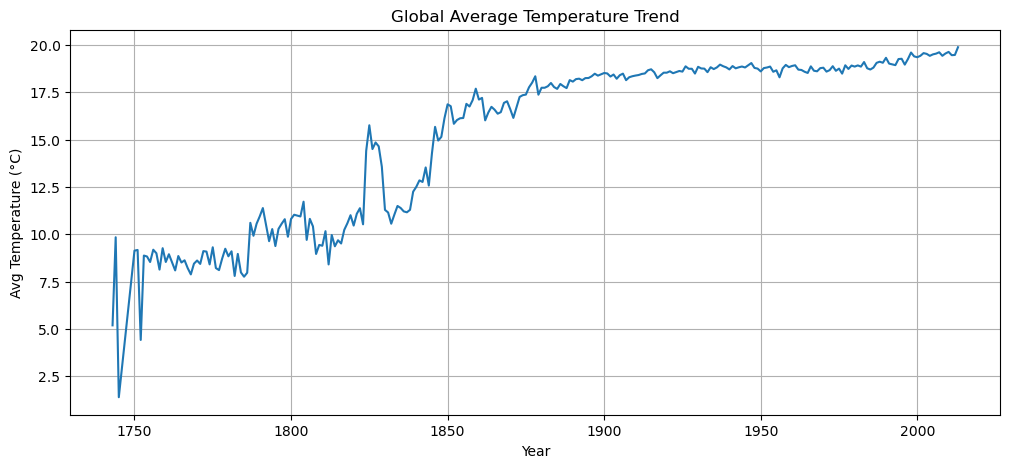

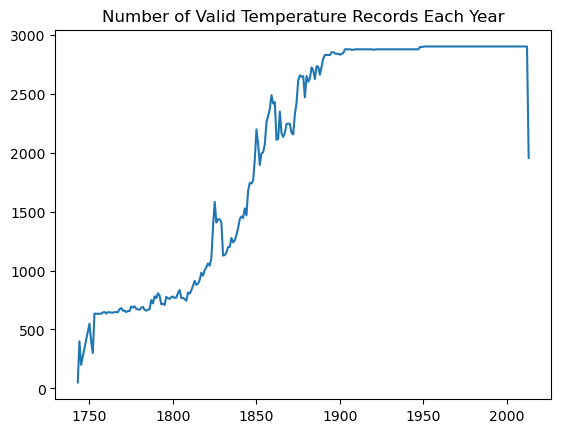

In [38]:
#计算全球年平均气温
###初步绘制查看温度趋势
global_temp=df.groupby("year")["AverageTemperature"].mean()
plt.figure(figsize=(12,5))
plt.plot(global_temp.index,global_temp.values)
plt.title("Global Average Temperature Trend")
plt.xlabel('Year')
plt.ylabel("Avg Temperature (°C)")
plt.grid(True)
plt.show()
years_counts = df.groupby("year")["AverageTemperature"].count()#每年平均温度的数量
plt.plot(years_counts.index, years_counts.values)
plt.title("Number of Valid Temperature Records Each Year")
plt.show()

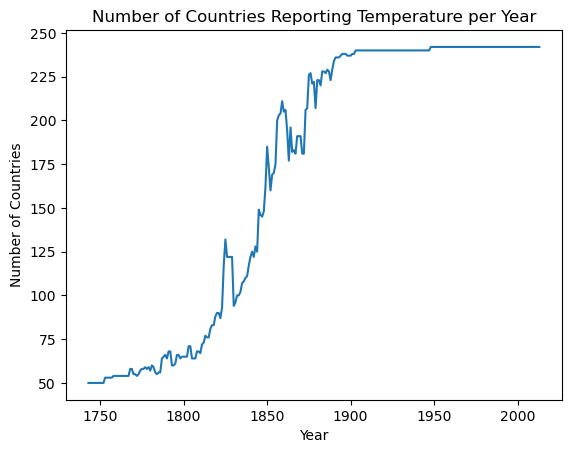

In [39]:
countries_per_year = df.groupby("year")["Country"].nunique()

plt.plot(countries_per_year)
plt.title("Number of Countries Reporting Temperature per Year")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.show()


- 出现了早些年份数据波动过大
- 出现了不符合事实的情况：1830年左右大幅度先升后降
    
需要事实：真实全球温度变化不会在 20 年内突然升降 2°C 以上    
研究数据存在的真实原因：

    1. 看图发现新增了很多数据，可能在热带地区修了观测点

    2. >数据插补（imputation）算法导致的虚假趋势
    
解决方向：

    1. 首先定位真实原因，发现国家不同了

    2. 分析时剔除1880年之前的数据
    
    3. rolling去除噪点

不是观测导致的变化
而是“空间重建模型”本身在变化
>1796：插值模型高估印度 → 全球均值上升

>1805：插值模型下调估计 → 全球均值下降

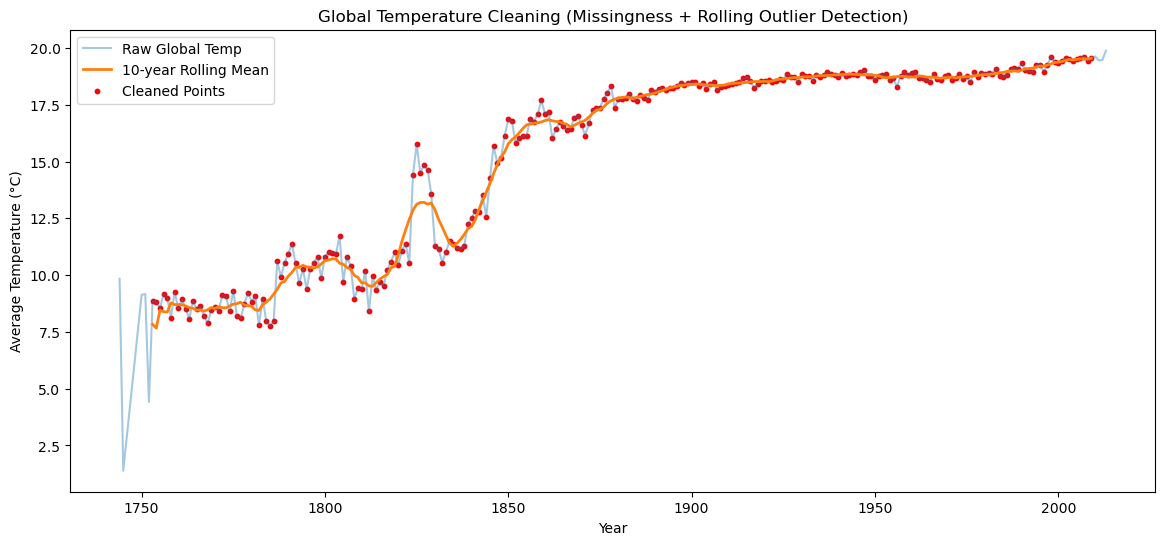

In [40]:
#使用合适的绘图库可视化全球长期气温趋势
#进一步清洗数据，并可视化
valid_years=years_counts[years_counts>50].index#每年平均温度数量大于50的每年平均温度的index
df_min50 = df[df["year"].isin(valid_years)]#平均温度大于50的年份

global_temp = df_min50.groupby("year")["AverageTemperature"].mean()#每年的国家测量的温度平均，代表该年的平均温度
rolling = global_temp.rolling(window=10, center=True).mean()
threshold = 3
mask = (global_temp - rolling).abs() < threshold
clean_temp = global_temp[mask]#进一步去除噪点

df_clear = df_min50[df_min50["year"].isin(clean_temp.index)]#测量数大于50且去除噪点的年份

df_clear.head()

plt.figure(figsize=(14,6))
plt.plot(global_temp.index, global_temp.values, label="Raw Global Temp", alpha=0.4)#
plt.plot(rolling.index, rolling.values, label="10-year Rolling Mean", linewidth=2)#窗口滑动的平均值
plt.scatter(clean_temp.index, clean_temp.values, label="Cleaned Points", color='red', s=10)
plt.legend()
plt.title("Global Temperature Cleaning (Missingness + Rolling Outlier Detection)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.show()

In [41]:
#计算并显示关键描述性统计数据（例如，平均值、中位数、标准差）。
desc_stats = df_min50.groupby("year")["AverageTemperature"].agg(
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max",
    count="count"
)

desc_stats.head()

,mean,median,std,min,max,count
year,,,,,,
1744,9.837898,10.4930,6.173708,-9.629,23.939,400
1745,1.387125,1.8650,5.478019,-12.564,12.707,200
1750,9.129353,8.8150,7.500505,-11.859,26.096,550
1751,9.167388,9.6600,8.562733,-14.845,25.283,400
1752,4.413387,5.5665,5.126480,-13.422,14.849,300


In [42]:

#上升最快的国家前五
from sklearn.linear_model import LinearRegression

results = []
df_1880=df[df['year']>=1880]
# 对每个国家计算升温 slope
for country, group in df_1880.groupby("Country"):
    # 每国年度平均
    yearly = group.groupby("year")["AverageTemperature"].mean()

    # 排除数据不足国家
    if len(yearly) < 20:
        continue

    # X, y
    X = yearly.index.values.reshape(-1, 1)#变成一列，行数懒得算
    y = yearly.values

    # 线性回归
    model = LinearRegression()
    model.fit(X, y)
    slope = model.coef_[0]

    # 存储结果
    results.append((country, slope))

# 转成 DataFrame
df_slope = pd.DataFrame(results, columns=["Country", "Slope"])
df_slope = df_slope.sort_values(by="Slope", ascending=False)

# 取升温最快 Top 5
top5 = df_slope.head(5)
top5

,Country,Slope
79,French Southern And Antarctic Lands,0.016397
38,Canada,0.016365
114,Kazakhstan,0.016044
143,Mongolia,0.015106
233,Uzbekistan,0.015079


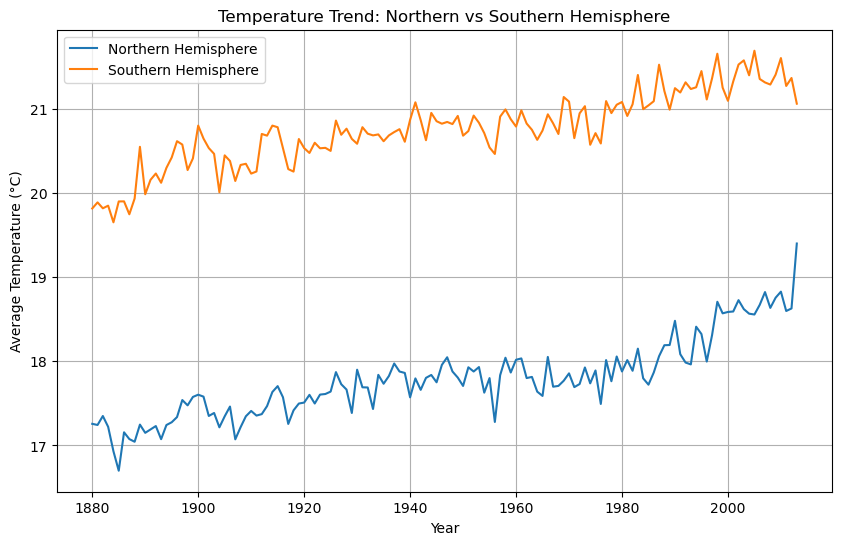

In [ ]:
#分析并比较南北半球的温度变化趋势
def lat_to_float(lat):
    value = float(lat[:-1])
    return value if lat.endswith("N") else -value

city_df = pd.read_csv("./data/GlobalLandTemperaturesByCity.csv")
city_df = city_df.dropna(subset=["AverageTemperature"])
city_df["Latitude_num"] = city_df["Latitude"].apply(lat_to_float)

# 把主要城市的纬度取平均
country_lat = city_df.groupby("Country")["Latitude_num"].mean().reset_index()

country_lat.head()

country_lat["hemisphere"] = country_lat["Latitude_num"].apply(lambda x: "Northern" if x > 0 else "Southern")

df_1880 = df_1880.merge(country_lat[["Country", "hemisphere"]], on="Country", how="left")

north = df_1880[df_1880["hemisphere"] == "Northern"].groupby("year")["AverageTemperature"].mean()
south = df_1880[df_1880["hemisphere"] == "Southern"].groupby("year")["AverageTemperature"].mean()

plt.figure(figsize=(10,6))
plt.plot(north.index, north.values, label="Northern Hemisphere")
plt.plot(south.index, south.values, label="Southern Hemisphere")
plt.legend()
plt.title("Temperature Trend: Northern vs Southern Hemisphere")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

1. On Absolute Temperature: Geographical Bias
Higher average temperatures in the South are due to land distribution.

- English: Southern landmasses are concentrated in warm tropical and subtropical latitudes. Conversely, Northern landmasses extend deep into the freezing Arctic circle, significantly dragging down the average.

- Chinese: 地理采样的“幸存者偏差”。南半球的陆地主要集中在温暖的低中纬度；而北半球的陆地一直延伸至寒冷的高纬度极地区域，拉低了整体均值。

2. On Volatility: Thermal Inertia
Smoother trends in the South are due to the "Thermostat Effect" of oceans.

- English: The Southern Hemisphere is 81% ocean. Water's high specific heat capacity creates massive thermal inertia, buffering against short-term fluctuations. The land-heavy North lacks this buffer, leading to "spikier" data.

- Chinese: 海洋的“恒温器”效应。南半球是“水半球”（81%是海洋），巨大的热惯性平抑了气温波动；北半球陆地多，比热容小，对气候变化的反应更加剧烈和敏感。

In [52]:
###做线性回归
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
global_temp_1880 = df[df["year"] >= 1880].groupby("year")["AverageTemperature"].mean()

# 去除 NaN 年份
global_temp_1880 = global_temp_1880.dropna()

#设计窗口，去除噪点
rolling = global_temp_1880.rolling(10, center=True).mean()
diff = (global_temp_1880 - rolling).abs()

# 自动剔除偏离超过 1.5°C 的点
clean_temp = global_temp_1880[diff < 1.5]#大于1880年，且去除噪点的年份的数据

# 拆分 X, y
years = clean_temp.index.values.reshape(-1, 1)#转化为2维数组，机器学习要求输入特征必须是二维数组
temps = clean_temp.values 

model=LinearRegression()
model.fit(years,temps)
predicted=model.predict(years)
last_year = years.max()
#预测未来三十年数据
future_years = np.arange(last_year+1, last_year+31).reshape(-1, 1)
future_pred = model.predict(future_years)

# 计算评估指标：对比“真实值 temps”和“模型预测值 predicted”
mse = mean_squared_error(temps, predicted)
r2 = r2_score(temps, predicted)

print(f"均方误差 (MSE): {mse:.4f}")
print(f"决定系数 (R²): {r2:.4f}")

均方误差 (MSE): 0.0407
决定系数 (R²): 0.7279


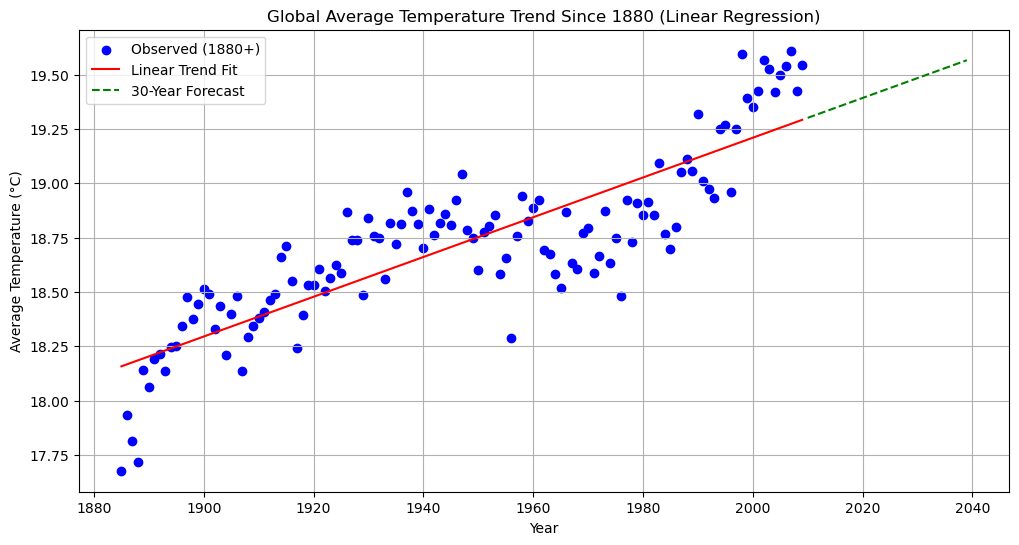

In [45]:
###模型评估
plt.figure(figsize=(12,6))

plt.scatter(years, temps, color='blue', label="Observed (1880+)")
plt.plot(years, predicted, color='red', label="Linear Trend Fit")
plt.plot(future_years, future_pred, color='green', linestyle='--', 
         label="30-Year Forecast")

plt.title("Global Average Temperature Trend Since 1880 (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

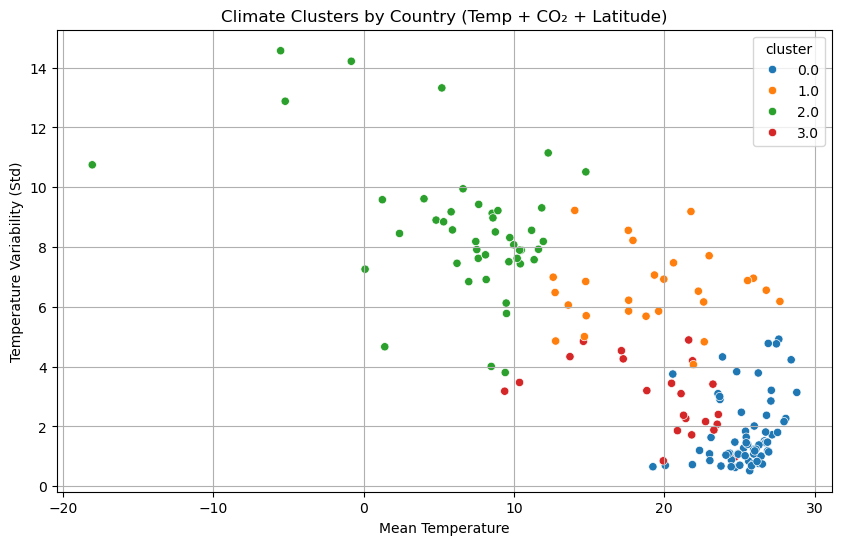

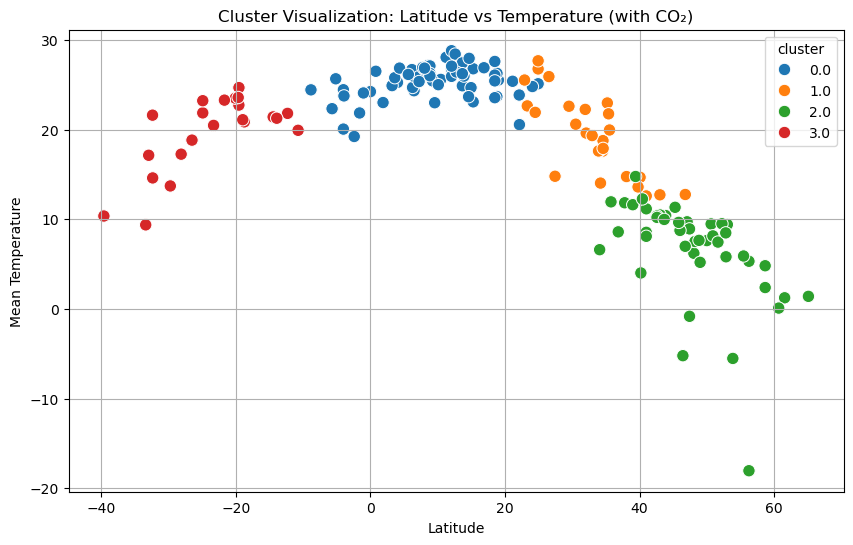

In [ ]:
#温度与CO2聚类
#每个国家的平均值，标准差
country_features = df_min50.groupby("Country")["AverageTemperature"].agg(
    mean_temp="mean",
    std_temp="std"
).reset_index()

#得到co2数据
co2 = pd.read_csv("./data/co2_1880_2023.csv")
co2_mean = co2["co2_ppm"].mean()
co2_last = co2["co2_ppm"].iloc[-1]

# 给每个国家一个相同的 CO₂（全球性变量）
country_features["co2_mean"] = co2_mean
country_features["co2_2023"] = co2_last

#加入国家，纬度的数据
country_features = country_features.merge(
    country_lat[["Country", "Latitude_num"]],
    on="Country",
    how="left"
)

#聚类特征
features = ["mean_temp", "std_temp", "Latitude_num", "co2_2023"]

X = country_features[features].copy()
X_clean = X.dropna()       # 参与聚类的国家
valid_idx = X_clean.index  # 保存这些国家的索引

#每一列数据都变成 均值=0，方差=1 的分布
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

#K-Means 聚类
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

#将聚类结果写回对应国家
country_features["cluster"] = np.nan        # 先填 NaN
country_features.loc[valid_idx, "cluster"] = clusters  # 只填参与聚类的国家

#可视化 1 - mean_temp vs std_temp
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=country_features,
    x="mean_temp",
    y="std_temp",
    hue="cluster",
    palette="tab10"
)
plt.title("Climate Clusters by Country (Temp + CO₂ + Latitude)")
plt.xlabel("Mean Temperature")
plt.ylabel("Temperature Variability (Std)")
plt.grid(True)
plt.show()


#可视化 2 - Latitude vs mean_temp (气候带结构)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=country_features,
    x="Latitude_num",
    y="mean_temp",
    hue="cluster",
    palette="tab10",
    s=80
)
plt.title("Cluster Visualization: Latitude vs Temperature (with CO₂)")
plt.xlabel("Latitude")
plt.ylabel("Mean Temperature")
plt.grid(True)
plt.show()




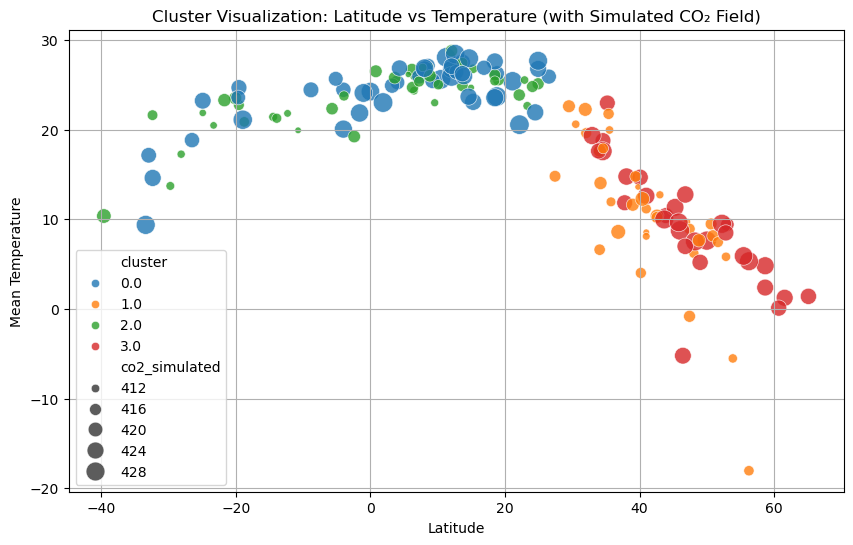

In [ ]:
#模拟co2全球区域场
np.random.seed(42)  # 固定随机种子，保证复现性

# 基于全球 CO₂ 添加区域噪声
country_features["co2_simulated"] = (
    country_features["co2_2023"] +
    np.random.uniform(-10, 10, size=len(country_features))
)

features = ["mean_temp", "std_temp", "Latitude_num", "co2_simulated"]
X = country_features[features].dropna()
valid_idx = X.index
#标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#四维聚类，图像画不出来
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

country_features["cluster"] = np.nan
country_features.loc[valid_idx, "cluster"] = clusters

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=country_features,
    x="Latitude_num",
    y="mean_temp",
    hue="cluster",
    size="co2_simulated",
    sizes=(20, 200),
    palette="tab10",
    alpha=0.8
)
plt.title("Cluster Visualization: Latitude vs Temperature (with Simulated CO₂ Field)")
plt.xlabel("Latitude")
plt.ylabel("Mean Temperature")
plt.grid(True)
plt.show()


In [ ]:
import plotly.express as px

#国家名 → ISO3 代码映射表（Plotly 内置）
gap = px.data.gapminder().query("year==2007")[["country","iso_alpha"]]

#国家表与 gapminder 的国家名匹配（可能部分国家无法匹配，正常）
country_iso = country_features.merge(
    gap,
    left_on="Country",
    right_on="country",
    how="left"
)

# 只需要部分列
country_iso = country_iso[["Country","iso_alpha","co2_simulated","cluster","mean_temp","Latitude_num"]]

fig = px.choropleth(
    country_iso,
    locations="iso_alpha",
    color="co2_simulated",  # 地图颜色 = 模拟 CO₂ 值
    hover_name="Country",
    hover_data={
        "co2_simulated": ":.2f",
        "mean_temp": ":.2f",
        "Latitude_num": ":.1f",
        "cluster": True
    },
    color_continuous_scale="Viridis",
    title="Simulated Regional CO₂ Field by Country",
    projection="natural earth"
)

fig.update_layout(height=600)

fig.show()

In [ ]:
# Annual global temperature (1880+)
annual_temp = df_min50.groupby("year")["AverageTemperature"].mean().reset_index()
annual_temp.rename(columns={"AverageTemperature": "temp"}, inplace=True)

co2.rename(columns={"co2_ppm": "co2"}, inplace=True)
df_tc = annual_temp.merge(co2, on="year", how="inner")
df_tc.head()
#temp去噪与co2去噪
df_tc["temp_roll10"] = df_tc["temp"].rolling(window=10, min_periods=1).mean()
df_tc["co2_roll10"] = df_tc["co2"].rolling(window=10, min_periods=1).mean()
corr = df_tc[["temp", "co2", "temp_roll10", "co2_roll10", "year"]].corr()
corr



,temp,co2,temp_roll10,co2_roll10,year
temp,1.000000,0.842859,0.947442,0.849842,0.879389
co2,0.842859,1.000000,0.846997,0.999073,0.930612
temp_roll10,0.947442,0.846997,1.000000,0.853381,0.922055
co2_roll10,0.849842,0.999073,0.853381,1.000000,0.925185
year,0.879389,0.930612,0.922055,0.925185,1.000000


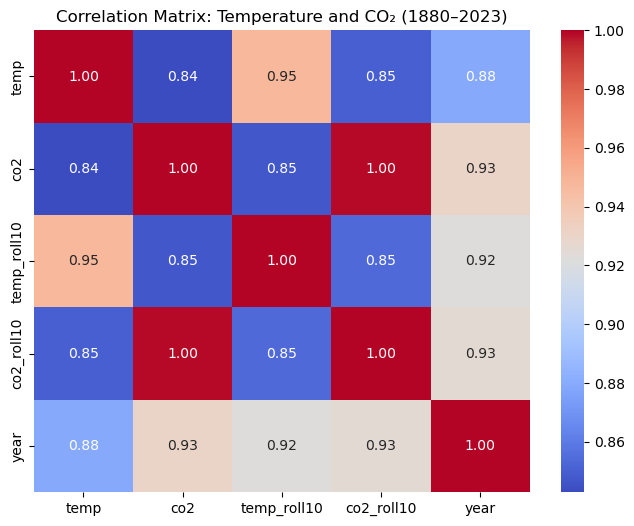

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Temperature and CO₂ (1880–2023)")
plt.show()


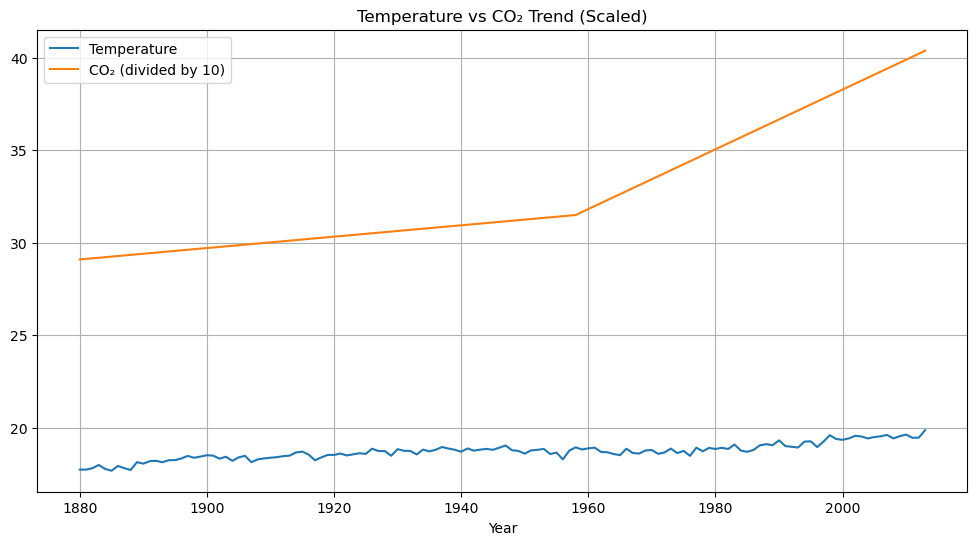

In [51]:
plt.figure(figsize=(12,6))
plt.plot(df_tc["year"], df_tc["temp"], label="Temperature")
plt.plot(df_tc["year"], df_tc["co2"]/10, label="CO₂ (divided by 10)")
plt.title("Temperature vs CO₂ Trend (Scaled)")
plt.xlabel("Year")
plt.legend()
plt.grid(True)
plt.show()


英文（专业版）

The correlation analysis shows a strong and positive relationship between atmospheric CO₂ concentration and global land temperature.
Using raw annual averages, the correlation is already high, but when applying a 10-year rolling mean the relationship becomes even stronger.
This reflects the fact that both temperature and CO₂ exhibit long-term upward trends driven by industrialization, while short-term variability can obscure the linear relationship.

The rolling mean removes year-to-year noise and exposes the underlying climate signal.
These results are consistent with modern climate science, which shows that rising greenhouse gas levels are closely associated with global warming over the past century.

中文（专业版）

相关性分析结果显示，大气 CO₂ 浓度与全球陆地温度之间存在显著的正相关关系。
使用年度原始数据时，两者已经表现出较高的相关性；在引入 10 年滚动平均后，相关性进一步增强。这体现了气候数据的本质：温度和 CO₂ 都具有长期上升趋势，而短期波动（如火山事件、ENSO）会削弱年度线性相关性。

滚动平均有效地去除了高频噪声，使长期气候信号更加明显。
这一结果与现代气候科学高度一致：温室气体的增加与近百年的全球变暖具有紧密的联系。